# Laplacian Pyramid

## Overview

The **Laplacian pyramid** is a classical multi-scale representation of images, introduced by Burt and Adelson (1983). It decomposes an image into a sequence of **bandpass residual images** plus a low-frequency base, enabling lossless reconstruction, efficient image blending, and HDR tone mapping.

### Why it matters

Images contain structure at many scales: fine textures, medium-scale edges, and coarse illumination gradients. The Laplacian pyramid isolates each scale as an independent layer, making it possible to process each frequency band separately before reassembling.

### Mathematical construction

**Gaussian pyramid.** Starting from $G_0 = $ original image, each level is obtained by low-pass filtering then subsampling:
$$G_j = \downarrow_2\bigl(\mathcal{G}_\sigma * G_{j-1}\bigr)$$
where $\mathcal{G}_\sigma$ is a Gaussian kernel with standard deviation $\sigma$, $*$ denotes convolution, and $\downarrow_2$ denotes 2x subsampling.

**Laplacian pyramid.** Each level is the *difference* between consecutive Gaussian levels after upsampling:
$$L_j = G_j - \uparrow_2(G_{j+1})$$
where $\uparrow_2$ denotes 2x upsampling (bilinear or nearest-neighbor interpolation back to the size of $G_j$). Each $L_j$ is a bandpass image capturing frequencies between the resolutions of $G_j$ and $G_{j+1}$.

**Lossless reconstruction.** Given the Laplacian pyramid $\{L_0, L_1, \ldots, L_{N-1}, G_N\}$, the original image is recovered exactly by:
$$G_j = L_j + \uparrow_2(G_{j+1}), \quad j = N-1, N-2, \ldots, 0$$

**Image blending.** To blend images $A$ and $B$ with a mask $M$:
$$L_j^{\text{blend}} = M_j \cdot L_j^A + (1 - M_j) \cdot L_j^B$$
where $M_j$ is a Gaussian-blurred version of $M$ at scale $j$. Blending in the pyramid domain avoids seam artifacts.

### What this notebook demonstrates

1. Building a Gaussian pyramid from a synthetic image.
2. Building the Laplacian pyramid and visualizing each band.
3. Verifying lossless reconstruction ($\|G_0^{\text{recon}} - G_0\|_\infty \approx 0$).
4. Applying pyramid blending to seamlessly merge two images.

### Imports and setup

We use `numpy` for array operations, `scipy.ndimage.gaussian_filter` for Gaussian convolution, and `matplotlib` for visualization.

In [1]:
import numpy as np
import matplotlib
if 'get_ipython' not in globals():
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, zoom

rng = np.random.default_rng(42)

### Synthetic test image

We construct a synthetic image that contains structure at multiple scales:
- a smooth low-frequency background (large Gaussian blob),
- medium-frequency stripes,
- fine high-frequency checkerboard noise.

This ensures the pyramid decomposition has non-trivial content at every level.

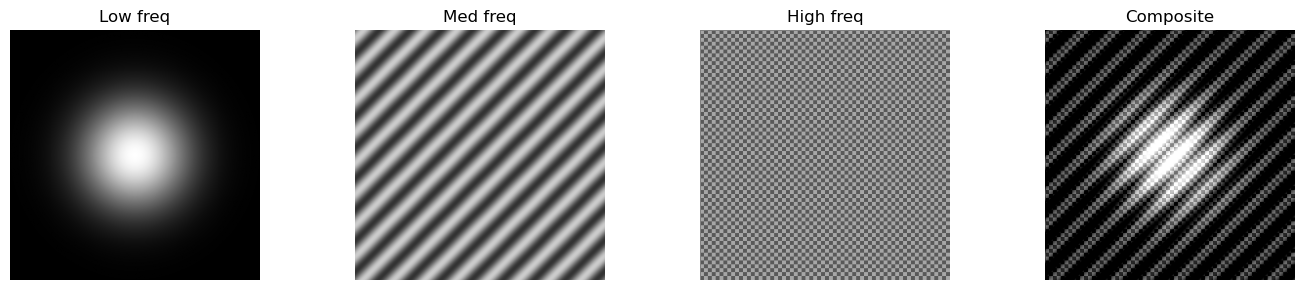

In [2]:
N = 256
x = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, x)

# Low-frequency component: smooth Gaussian blob
low_freq = np.exp(-((X - 0.5)**2 + (Y - 0.5)**2) / (2 * 0.15**2))

# Medium-frequency: diagonal stripes
med_freq = 0.3 * np.sin(2 * np.pi * 8 * (X + Y))

# High-frequency: checkerboard
hi_freq = 0.15 * np.sign(np.sin(2 * np.pi * 32 * X) * np.sin(2 * np.pi * 32 * Y))

image = np.clip(low_freq + med_freq + hi_freq, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, img, title in zip(axes,
                          [low_freq, med_freq + 0.5, hi_freq + 0.5, image],
                          ['Low freq', 'Med freq', 'High freq', 'Composite']):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()
plt.savefig('components.png', dpi=80, bbox_inches='tight')
plt.close()

### Gaussian pyramid construction

We implement the Gaussian pyramid by alternating Gaussian blurring and 2x subsampling. The key parameter is $\sigma$, chosen as $1.0$ pixel (after subsampling the effective scale doubles at each level).

$$G_j = \downarrow_2(\mathcal{G}_\sigma * G_{j-1})$$

Each level has half the spatial resolution of the previous one.

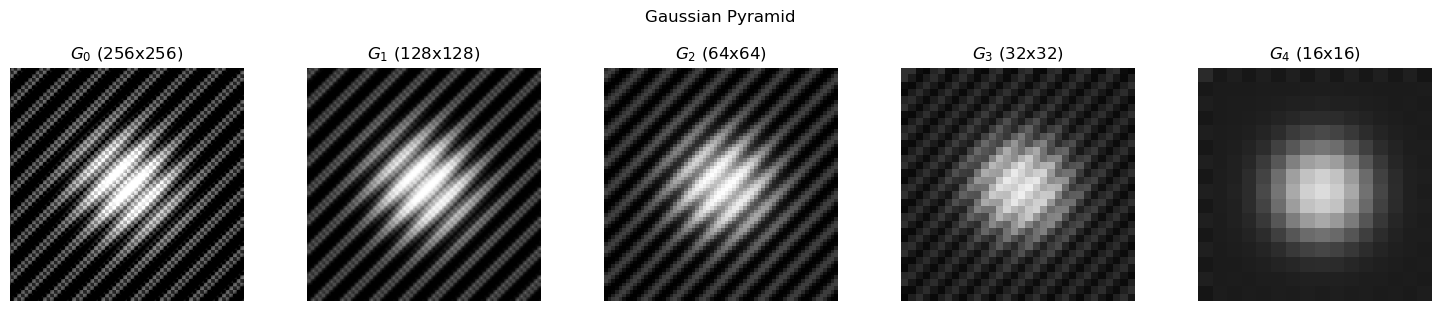

In [3]:
def gaussian_pyramid(img, n_levels=5, sigma=1.0):
    """Build Gaussian pyramid by blur + subsample."""
    pyramid = [img.astype(float)]
    for _ in range(n_levels - 1):
        blurred = gaussian_filter(pyramid[-1], sigma=sigma)
        subsampled = blurred[::2, ::2]
        pyramid.append(subsampled)
    return pyramid

N_LEVELS = 5
gpyr = gaussian_pyramid(image, n_levels=N_LEVELS)

fig, axes = plt.subplots(1, N_LEVELS, figsize=(15, 3))
for j, (ax, g) in enumerate(zip(axes, gpyr)):
    ax.imshow(g, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'$G_{j}$ ({g.shape[0]}x{g.shape[1]})')
    ax.axis('off')
plt.suptitle('Gaussian Pyramid', y=1.02)
plt.tight_layout()
plt.show()
plt.savefig('gaussian_pyramid.png', dpi=80, bbox_inches='tight')
plt.close()

### Laplacian pyramid construction

The Laplacian pyramid is built from the Gaussian pyramid by subtracting adjacent levels after upsampling. Upsampling is done with `scipy.ndimage.zoom` using bilinear interpolation.

$$L_j = G_j - \uparrow_2(G_{j+1})$$

Each $L_j$ encodes the *residual* that was lost by the downsampling step, i.e. the content in a specific frequency band. The last level $G_{N-1}$ is retained as-is (the coarsest low-frequency residual).

Note: the Laplacian levels contain both positive and negative values, displayed here centered at $0.5$.

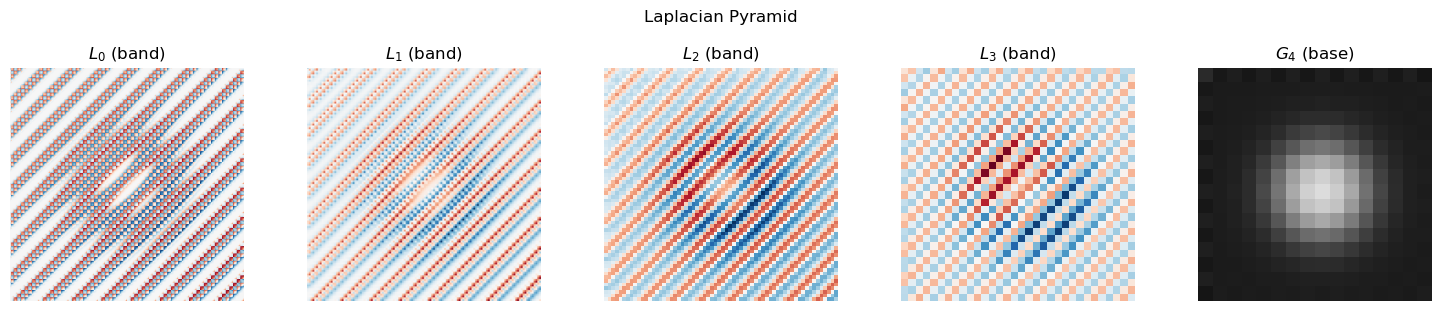

In [4]:
def upsample(img, target_shape):
    """Upsample img to target_shape using bilinear zoom."""
    factors = (target_shape[0] / img.shape[0], target_shape[1] / img.shape[1])
    return zoom(img, factors, order=1)

def laplacian_pyramid(gpyr):
    """Build Laplacian pyramid from Gaussian pyramid."""
    lpyr = []
    for j in range(len(gpyr) - 1):
        up = upsample(gpyr[j + 1], gpyr[j].shape)
        lpyr.append(gpyr[j] - up)
    lpyr.append(gpyr[-1])  # coarsest level retained
    return lpyr

lpyr = laplacian_pyramid(gpyr)

fig, axes = plt.subplots(1, N_LEVELS, figsize=(15, 3))
for j, (ax, L) in enumerate(zip(axes, lpyr)):
    if j < N_LEVELS - 1:
        # Laplacian levels: center at 0.5 for display
        vmax = np.abs(L).max() + 1e-8
        ax.imshow(L, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        ax.set_title(f'$L_{j}$ (band)')
    else:
        ax.imshow(L, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'$G_{j}$ (base)')
    ax.axis('off')
plt.suptitle('Laplacian Pyramid', y=1.02)
plt.tight_layout()
plt.show()
plt.savefig('laplacian_pyramid.png', dpi=80, bbox_inches='tight')
plt.close()

### Lossless reconstruction

The reconstruction proceeds from coarse to fine by iterating:
$$G_j = L_j + \uparrow_2(G_{j+1})$$

This is exact (up to floating-point round-off), confirming that the Laplacian pyramid is a **lossless** representation. We verify by computing the maximum absolute reconstruction error $\|G_0^{\text{recon}} - G_0\|_\infty$.

Max reconstruction error: 1.11e-16


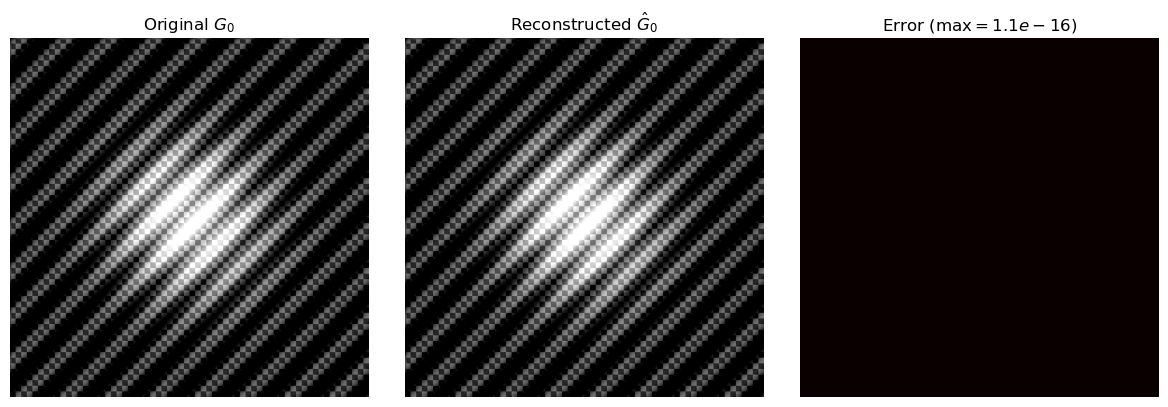

In [5]:
def reconstruct_from_laplacian(lpyr):
    """Reconstruct image from Laplacian pyramid."""
    recon = lpyr[-1].copy()
    for j in range(len(lpyr) - 2, -1, -1):
        up = upsample(recon, lpyr[j].shape)
        recon = lpyr[j] + up
    return recon

recon = reconstruct_from_laplacian(lpyr)
error = np.abs(recon - image).max()
print(f'Max reconstruction error: {error:.2e}')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(image, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original $G_0$')
axes[0].axis('off')
axes[1].imshow(recon, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Reconstructed $\\hat{G}_0$')
axes[1].axis('off')
diff = np.abs(recon - image)
axes[2].imshow(diff, cmap='hot', vmin=0, vmax=1e-10)
axes[2].set_title(f'Error ($\\max = {error:.1e}$)')
axes[2].axis('off')
plt.tight_layout()
plt.show()
plt.savefig('reconstruction.png', dpi=80, bbox_inches='tight')
plt.close()

### Pyramid image blending

One of the key applications of the Laplacian pyramid is **seamless image blending**. Given two images $A$, $B$ and a binary mask $M$, blending is performed in the pyramid domain:

$$L_j^{\text{blend}} = M_j \odot L_j^A + (1 - M_j) \odot L_j^B$$

where $M_j = \downarrow_{2^j}(\mathcal{G}_{\sigma_j} * M)$ is the Gaussian-blurred and downsampled mask at scale $j$. Blending smooth masks at each scale prevents the hard seam artifacts that would appear from a direct pixel-level mask.

We blend two synthetic images: one with horizontal stripes, one with a radial pattern, using a smooth vertical transition mask.

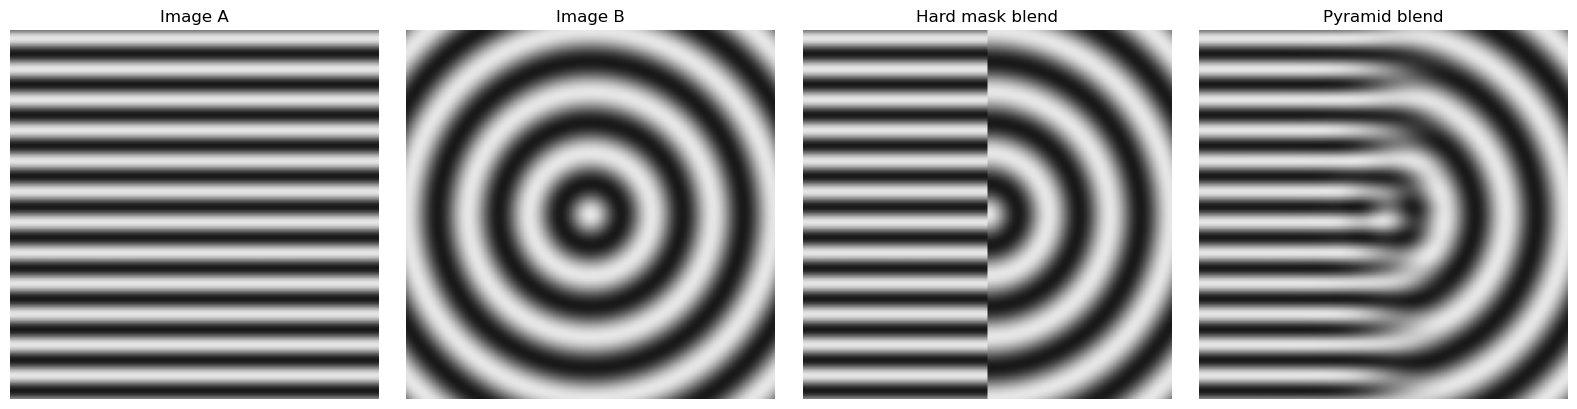

In [6]:
# Create two synthetic images to blend
imgA = np.clip(0.5 + 0.4 * np.sin(2 * np.pi * 12 * Y), 0, 1)   # horizontal stripes
imgB = np.clip(0.5 + 0.4 * np.cos(2 * np.pi * 6 * np.sqrt((X - 0.5)**2 + (Y - 0.5)**2)), 0, 1)  # rings

# Vertical mask: left half = A, right half = B, smooth transition
mask = np.zeros((N, N))
mask[:, :N // 2] = 1.0
mask_smooth = gaussian_filter(mask.astype(float), sigma=20)

# Build pyramids
gpyrA = gaussian_pyramid(imgA, N_LEVELS)
gpyrB = gaussian_pyramid(imgB, N_LEVELS)
gpyrM = gaussian_pyramid(mask_smooth, N_LEVELS)

lpyrA = laplacian_pyramid(gpyrA)
lpyrB = laplacian_pyramid(gpyrB)

# Blend in pyramid domain
lpyr_blend = []
for j in range(N_LEVELS):
    m = gpyrM[j]
    blended_level = m * lpyrA[j] + (1 - m) * lpyrB[j]
    lpyr_blend.append(blended_level)

# Reconstruct blended image
blended = np.clip(reconstruct_from_laplacian(lpyr_blend), 0, 1)

# Naive blending (hard mask)
naive = mask * imgA + (1 - mask) * imgB

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, img, title in zip(axes,
                          [imgA, imgB, naive, blended],
                          ['Image A', 'Image B', 'Hard mask blend', 'Pyramid blend']):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()
plt.savefig('blending.png', dpi=80, bbox_inches='tight')
plt.close()

### Energy distribution across scales

The energy $\|L_j\|_F^2$ at each Laplacian level reveals how much signal content lives at each spatial scale. For natural images, energy typically decreases with frequency (pink noise character), while images with dominant textures may show peaks at specific scales.

We plot the energy profile and visualize all Laplacian levels at their native resolution side by side.

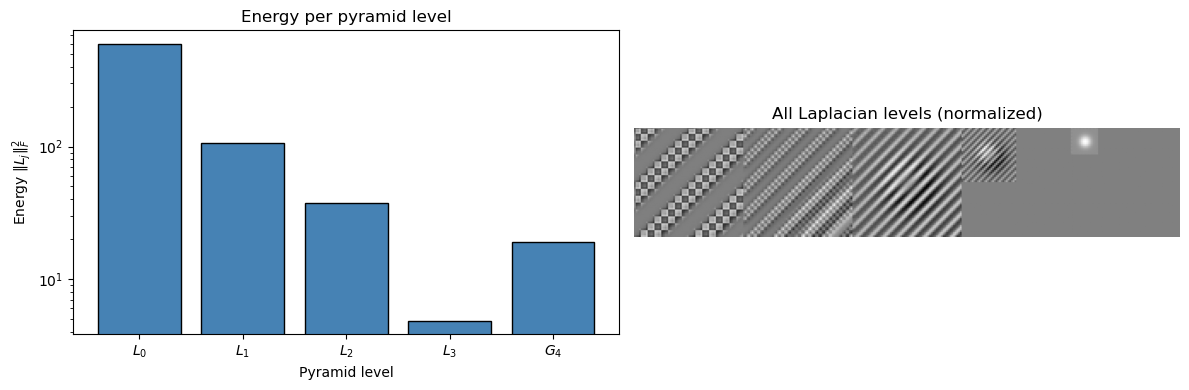

In [7]:
energies = [np.sum(L**2) for L in lpyr]
levels = list(range(N_LEVELS))
labels = [f'$L_{j}$' for j in range(N_LEVELS - 1)] + [f'$G_{N_LEVELS-1}$']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(levels, energies, color='steelblue', edgecolor='k')
ax1.set_xticks(levels)
ax1.set_xticklabels(labels)
ax1.set_xlabel('Pyramid level')
ax1.set_ylabel('Energy $\\|L_j\\|_F^2$')
ax1.set_title('Energy per pyramid level')
ax1.set_yscale('log')

# Composite display: all levels padded to same display size
disp_size = 64
strip = []
for j, L in enumerate(lpyr):
    padded = np.ones((disp_size, disp_size)) * 0.5
    s = min(L.shape[0], disp_size)
    padded[:s, :s] = np.clip(0.5 + L[:s, :s] / (np.abs(L).max() + 1e-8) * 0.5, 0, 1)
    strip.append(padded)
composite = np.concatenate(strip, axis=1)
ax2.imshow(composite, cmap='gray', vmin=0, vmax=1)
ax2.set_title('All Laplacian levels (normalized)')
ax2.axis('off')

plt.tight_layout()
plt.show()
plt.savefig('energy_levels.png', dpi=80, bbox_inches='tight')
plt.close()

### Interactive exploration

The widget below lets you explore the Laplacian pyramid interactively. Use the slider to select which pyramid level to display, and toggle between the Gaussian level $G_j$ and the Laplacian band $L_j$.

### Static snapshot (for automated execution)

The following cell generates `snippet.png`, a representative summary figure of the pyramid decomposition, used when running in non-interactive mode.

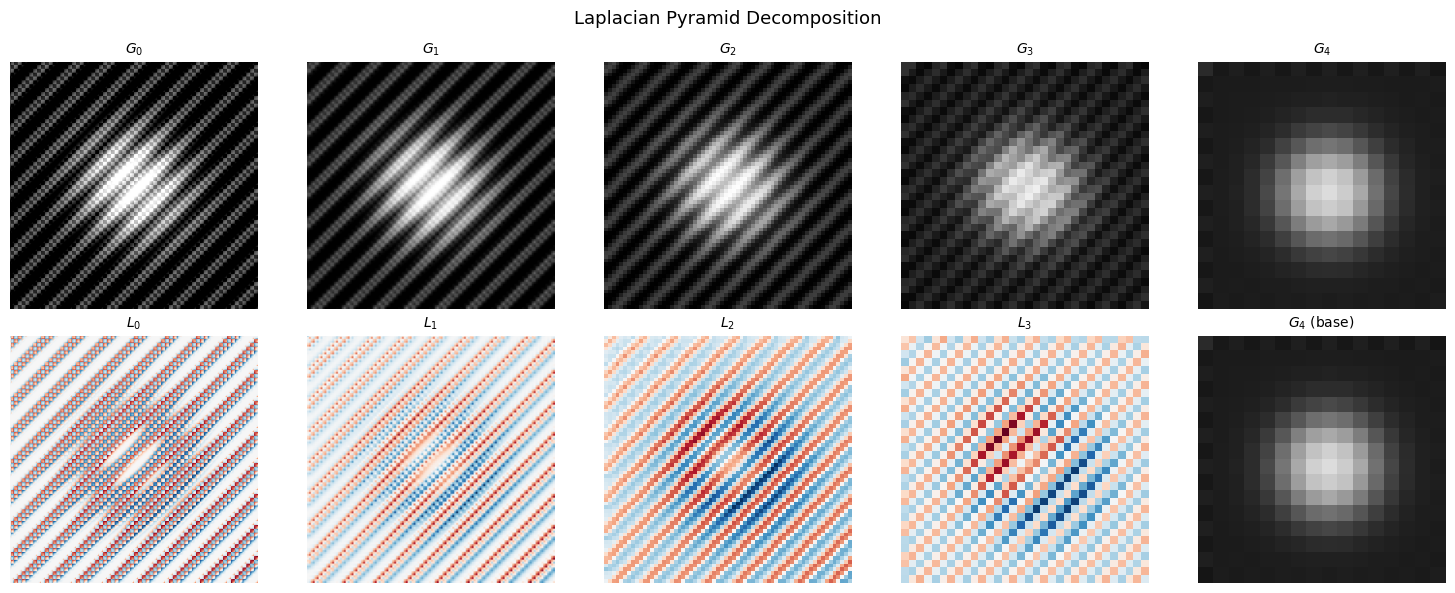

In [8]:
STATIC_SNAPSHOT = True
if STATIC_SNAPSHOT:
    fig, axes = plt.subplots(2, N_LEVELS, figsize=(15, 6))
    for j in range(N_LEVELS):
        axes[0, j].imshow(gpyr[j], cmap='gray', vmin=0, vmax=1)
        axes[0, j].set_title(f'$G_{j}$', fontsize=10)
        axes[0, j].axis('off')
        L = lpyr[j]
        if j < N_LEVELS - 1:
            vmax = np.abs(L).max() + 1e-8
            axes[1, j].imshow(L, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
            axes[1, j].set_title(f'$L_{j}$', fontsize=10)
        else:
            axes[1, j].imshow(L, cmap='gray', vmin=0, vmax=1)
            axes[1, j].set_title(f'$G_{j}$ (base)', fontsize=10)
        axes[1, j].axis('off')
    axes[0, 0].set_ylabel('Gaussian', fontsize=10)
    axes[1, 0].set_ylabel('Laplacian', fontsize=10)
    plt.suptitle('Laplacian Pyramid Decomposition', fontsize=13)
    plt.tight_layout()
    plt.show()
    plt.savefig('snippet.png', dpi=100, bbox_inches='tight')
    plt.close()

## Takeaways

- The **Gaussian pyramid** progressively blurs and downsamples an image, creating a coarse-to-fine hierarchy.
- The **Laplacian pyramid** stores the bandpass residuals between consecutive Gaussian levels; together with the coarsest Gaussian level, it forms a **lossless** representation.
- Reconstruction error is at floating-point machine precision, confirming perfect invertibility.
- **Pyramid blending** blends images at each frequency band separately using a smoothed mask, avoiding sharp seam artifacts that appear with naive direct blending.
- Energy is typically concentrated in low-frequency levels; high-frequency levels are sparse and carry fine detail.

## Bibliography

- P. J. Burt and E. H. Adelson, *The Laplacian pyramid as a compact image code*, IEEE Transactions on Communications, 31(4):532–540, 1983.
- P. J. Burt and E. H. Adelson, *A multiresolution spline with application to image mosaics*, ACM Transactions on Graphics, 2(4):217–236, 1983.
- S. Mallat, *A Wavelet Tour of Signal Processing*, Academic Press, 3rd edition, 2009.
- R. Szeliski, *Computer Vision: Algorithms and Applications*, Springer, 2010. Chapter 3.